<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/CNN-model/CNN-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone --branch CNN-model --single-branch https://github.com/dokunoale/chagas.git
%cd chagas
# Carica librerie installate
!pip install wfdb -q
!pip install gdown -q

# Aggiungi solo la root del progetto (src)
import sys
sys.path.append('/content/chagas/src')

# Importa tutto dai moduli
from preprocessing import tf_dataset_loader
from models import libraries, functions, split_dataset
from models.CNN import build_model

# Importa simboli specifici (se vuoi)
from models.libraries import *
from models.functions import *
from models.split_dataset import *
from models.CNN.build_model import *


Cloning into 'chagas'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 156 (delta 59), reused 65 (delta 31), pack-reused 45 (from 1)
Receiving objects: 100% (156/156), 208.48 KiB | 1.80 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/chagas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas

In [3]:
from google.colab import drive
drive.mount('/content/drive')

url = "https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_
From (redirected): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_&confirm=t&uuid=8ab1775f-b165-4085-8d76-235e42ce86ae
To: /content/chagas/dataset.zip
100%|██████████| 435M/435M [00:05<00:00, 74.2MB/s]


In [4]:
X_pos, y_pos = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed/positives')
X_neg, y_neg = tf_dataset_loader.load_dataset('/content/chagas/dataset/preprocessed/negatives')

In [5]:
#Uniamo i positivi e i negativi
X = np.concatenate([X_pos, X_neg], axis=0)
y = np.concatenate([y_pos, y_neg], axis=0)

# Facciamo lo shuffle
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# Riordinamento di X e y con gli stessi indici
X = X[indices]
y = y[indices]

In [6]:
#SPLIT DEL DATASET
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)

In [7]:
# mettiamo le etichette sottoforma di 0 e 1
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print(np.unique(y_train))

[0 1]


# Primo modello: usiamo la BCE

In [8]:
model1 = build_cnn_ecg_model()

#compiliamo il modello
model1.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("1_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history1 = model1.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)



Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.6679 - auc: 0.7010 - loss: 0.6329
Epoch 1: val_auc improved from -inf to 0.68925, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 85s 600ms/step - accuracy: 0.6680 - auc: 0.7011 - loss: 0.6328 - val_accuracy: 0.7489 - val_auc: 0.6893 - val_loss: 0.5879 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.7008 - auc: 0.7285 - loss: 0.6016
Epoch 2: val_auc improved from 0.68925 to 0.76887, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 593ms/step - accuracy: 0.7009 - auc: 0.7286 - loss: 0.6016 - val_accuracy: 0.7525 - val_auc: 0.7689 - val_loss: 0.5573 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.7514 - auc: 0.7842 - loss: 0.5567
Epoch 3: val_auc improved from 0.76887 to 0.77862, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 83s 615ms/step - accuracy: 0.7513 - auc: 0.7841 - loss: 0.5568 - val_accuracy: 0.7384 - val_auc: 0.7786 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.7297 - auc: 0.7740 - loss: 0.5784
Epoch 4: val_auc improved from 0.77862 to 0.78190, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 146s 646ms/step - accuracy: 0.7297 - auc: 0.7741 - loss: 0.5783 - val_accuracy: 0.7328 - val_auc: 0.7819 - val_loss: 0.5417 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.7532 - auc: 0.8014 - loss: 0.5323
Epoch 5: val_auc improved from 0.78190 to 0.80304, saving model to 1_CNN_best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 80s 587ms/step - accuracy: 0.8480 - auc: 0.9429 - loss: 0.2841 - val_accuracy: 0.8177 - val_auc: 0.9174 - val_loss: 0.3650 - learning_rate: 0.0010
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8379 - auc: 0.9391 - loss: 0.3001
Epoch 22: val_auc did not improve from 0.91744
134/134 ━━━━━━━━━━━━━━━━━━━━ 84s 630ms/step - accuracy: 0.8379 - auc: 0.9391 - loss: 0.3001 - val_accuracy: 0.8008 - val_auc: 0.9137 - val_loss: 0.4628 - learning_rate: 0.0010
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8457 - auc: 0.9393 - loss: 0.2885
Epoch 23: val_auc did not improve from 0.91744
134/134 ━━━━━━━━━━━━━━━━━━━━ 136s 587ms/step - accuracy: 0.8457 - auc: 0.9393 - loss: 0.2884 - val_accuracy: 0.8050 - val_auc: 0.9114 - val_loss: 0.4607 - learning_rate: 0.0010
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.8625 - auc: 0.9498 - loss: 0.2615
Epoch 24: val_auc improved from 0.91744 to 0.91892, saving model to 

134/134 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.8624 - auc: 0.9498 - loss: 0.2615 - val_accuracy: 0.7924 - val_auc: 0.9189 - val_loss: 0.4427 - learning_rate: 0.0010
Epoch 25/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.8523 - auc: 0.9494 - loss: 0.2700
Epoch 25: val_auc did not improve from 0.91892
134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 628ms/step - accuracy: 0.8523 - auc: 0.9494 - loss: 0.2700 - val_accuracy: 0.8121 - val_auc: 0.9189 - val_loss: 0.4236 - learning_rate: 0.0010
Epoch 26/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.8383 - auc: 0.9383 - loss: 0.2978
Epoch 26: val_auc improved from 0.91892 to 0.91957, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 136s 585ms/step - accuracy: 0.8383 - auc: 0.9383 - loss: 0.2978 - val_accuracy: 0.8324 - val_auc: 0.9196 - val_loss: 0.3191 - learning_rate: 0.0010
Epoch 27/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8472 - auc: 0.9443 - loss: 0.2849
Epoch 27: val_auc improved from 0.91957 to 0.92221, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.8473 - auc: 0.9443 - loss: 0.2848 - val_accuracy: 0.8247 - val_auc: 0.9222 - val_loss: 0.3900 - learning_rate: 0.0010
Epoch 28/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.8716 - auc: 0.9535 - loss: 0.2537
Epoch 28: val_auc did not improve from 0.92221
134/134 ━━━━━━━━━━━━━━━━━━━━ 78s 586ms/step - accuracy: 0.8716 - auc: 0.9535 - loss: 0.2537 - val_accuracy: 0.8219 - val_auc: 0.9213 - val_loss: 0.3750 - learning_rate: 0.0010
Epoch 29/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.8682 - auc: 0.9578 - loss: 0.2407
Epoch 29: val_auc improved from 0.92221 to 0.92517, saving model to 1_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 580ms/step - accuracy: 0.8682 - auc: 0.9577 - loss: 0.2408 - val_accuracy: 0.8380 - val_auc: 0.9252 - val_loss: 0.3530 - learning_rate: 0.0010
Epoch 30/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.8707 - auc: 0.9588 - loss: 0.2364
Epoch 30: val_auc did not improve from 0.92517
134/134 ━━━━━━━━━━━━━━━━━━━━ 88s 622ms/step - accuracy: 0.8707 - auc: 0.9588 - loss: 0.2365 - val_accuracy: 0.8247 - val_auc: 0.9209 - val_loss: 0.4654 - learning_rate: 0.0010


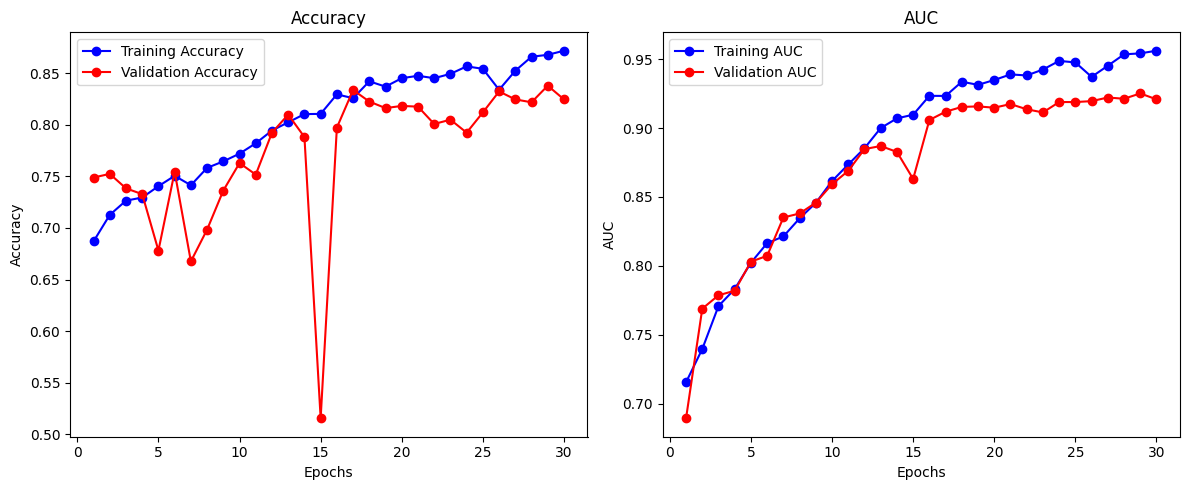

In [9]:
#visualizziamo l'andamento delle metriche durante l'addestramento
plot_training_metrics(history1)

In [10]:
!git pull origin CNN-model
from models import functions
importlib.reload(functions)

From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
Already up to date.


<module 'models.functions' from '/content/chagas/src/models/functions.py'>

In [34]:
#Facciamo le predizioni
y_pred_proba = model1.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step
Soglia ottimale: 0.433
Soglia ottimale: 0.433346152305603


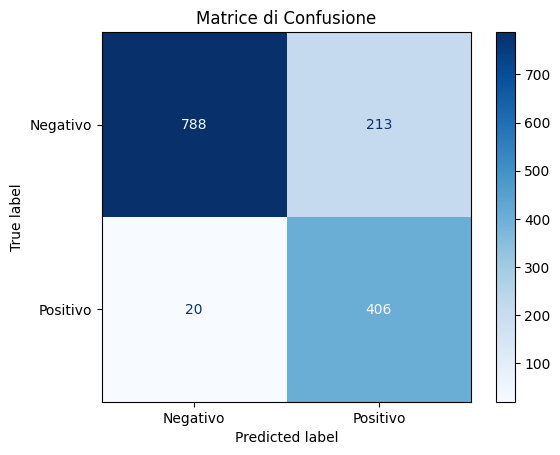

In [35]:
#Calcoliamo la matrice di confusione e la visualizziamo
from models import functions
importlib.reload(functions)
from models.functions import show_confusion_matrix

cm1 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm1)

In [36]:
#Vediamo i risultati
acc1 = accuracy_score(y_test, y_pred_binary)
auc1 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc1:.3f}")
print(f"AUC: {auc1:.3f}")

class_report1 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report1)
class_report1 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.837
AUC: 0.927
              precision    recall  f1-score   support

    Negativo       0.98      0.79      0.87      1001
    Positivo       0.66      0.95      0.78       426

    accuracy                           0.84      1427
   macro avg       0.82      0.87      0.82      1427
weighted avg       0.88      0.84      0.84      1427



In [37]:
model1.save('/content/drive/MyDrive/chagas_models/CNN_BCE.keras')

# Secondo modello: usiamo la focal loss

In [14]:
!git pull origin CNN-model
from models import functions
importlib.reload(functions)

From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
Already up to date.


<module 'models.functions' from '/content/chagas/src/models/functions.py'>

In [15]:
model2 = build_cnn_ecg_model()

#compiliamo il modello
model2.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("2_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history2 = model2.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.7174 - auc: 0.6629 - loss: 0.0444
Epoch 1: val_auc improved from -inf to 0.73031, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 88s 609ms/step - accuracy: 0.7176 - auc: 0.6631 - loss: 0.0444 - val_accuracy: 0.7153 - val_auc: 0.7303 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7543 - auc: 0.7194 - loss: 0.0350
Epoch 2: val_auc improved from 0.73031 to 0.76358, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 607ms/step - accuracy: 0.7543 - auc: 0.7196 - loss: 0.0350 - val_accuracy: 0.7489 - val_auc: 0.7636 - val_loss: 0.0340 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.7598 - auc: 0.7630 - loss: 0.0339
Epoch 3: val_auc improved from 0.76358 to 0.79289, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 638ms/step - accuracy: 0.7599 - auc: 0.7630 - loss: 0.0339 - val_accuracy: 0.7644 - val_auc: 0.7929 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7742 - auc: 0.7810 - loss: 0.0299
Epoch 4: val_auc did not improve from 0.79289
134/134 ━━━━━━━━━━━━━━━━━━━━ 138s 609ms/step - accuracy: 0.7741 - auc: 0.7810 - loss: 0.0299 - val_accuracy: 0.7602 - val_auc: 0.7889 - val_loss: 0.0328 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.7799 - auc: 0.7955 - loss: 0.0269
Epoch 5: val_auc improved from 0.79289 to 0.81505, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 146s 643ms/step - accuracy: 0.7798 - auc: 0.7955 - loss: 0.0269 - val_accuracy: 0.7742 - val_auc: 0.8150 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7707 - auc: 0.8071 - loss: 0.0291
Epoch 6: val_auc improved from 0.81505 to 0.82411, saving model to 2_CNN_best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 80s 600ms/step - accuracy: 0.8593 - auc: 0.9479 - loss: 0.0101 - val_accuracy: 0.8464 - val_auc: 0.9272 - val_loss: 0.0177 - learning_rate: 5.0000e-04
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8841 - auc: 0.9582 - loss: 0.0083
Epoch 22: val_auc improved from 0.92724 to 0.92862, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 612ms/step - accuracy: 0.8840 - auc: 0.9582 - loss: 0.0083 - val_accuracy: 0.8492 - val_auc: 0.9286 - val_loss: 0.0182 - learning_rate: 5.0000e-04
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.8736 - auc: 0.9560 - loss: 0.0088
Epoch 23: val_auc improved from 0.92862 to 0.93337, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 646ms/step - accuracy: 0.8736 - auc: 0.9560 - loss: 0.0088 - val_accuracy: 0.8548 - val_auc: 0.9334 - val_loss: 0.0192 - learning_rate: 5.0000e-04
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.8925 - auc: 0.9618 - loss: 0.0082
Epoch 24: val_auc improved from 0.93337 to 0.93731, saving model to 2_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 136s 604ms/step - accuracy: 0.8924 - auc: 0.9617 - loss: 0.0082 - val_accuracy: 0.8562 - val_auc: 0.9373 - val_loss: 0.0143 - learning_rate: 5.0000e-04
Epoch 25/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.8920 - auc: 0.9645 - loss: 0.0073
Epoch 25: val_auc did not improve from 0.93731
134/134 ━━━━━━━━━━━━━━━━━━━━ 89s 655ms/step - accuracy: 0.8920 - auc: 0.9644 - loss: 0.0073 - val_accuracy: 0.8576 - val_auc: 0.9360 - val_loss: 0.0147 - learning_rate: 5.0000e-04
Epoch 26/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.8888 - auc: 0.9640 - loss: 0.0077
Epoch 26: val_auc did not improve from 0.93731
134/134 ━━━━━━━━━━━━━━━━━━━━ 137s 613ms/step - accuracy: 0.8888 - auc: 0.9640 - loss: 0.0077 - val_accuracy: 0.8268 - val_auc: 0.9229 - val_loss: 0.0343 - learning_rate: 5.0000e-04
Epoch 27/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.8915 - auc: 0.9646 - loss: 0.0071
Epoch 27: val_auc did not improve from 0.93731
134/134 

134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 607ms/step - accuracy: 0.8988 - auc: 0.9688 - loss: 0.0067 - val_accuracy: 0.8647 - val_auc: 0.9390 - val_loss: 0.0173 - learning_rate: 2.5000e-04
Epoch 29/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.9024 - auc: 0.9729 - loss: 0.0064
Epoch 29: val_auc did not improve from 0.93897
134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 607ms/step - accuracy: 0.9024 - auc: 0.9728 - loss: 0.0064 - val_accuracy: 0.8569 - val_auc: 0.9364 - val_loss: 0.0243 - learning_rate: 2.5000e-04
Epoch 30/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9174 - auc: 0.9772 - loss: 0.0052
Epoch 30: val_auc did not improve from 0.93897
134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 610ms/step - accuracy: 0.9174 - auc: 0.9771 - loss: 0.0052 - val_accuracy: 0.8527 - val_auc: 0.9314 - val_loss: 0.0268 - learning_rate: 2.5000e-04


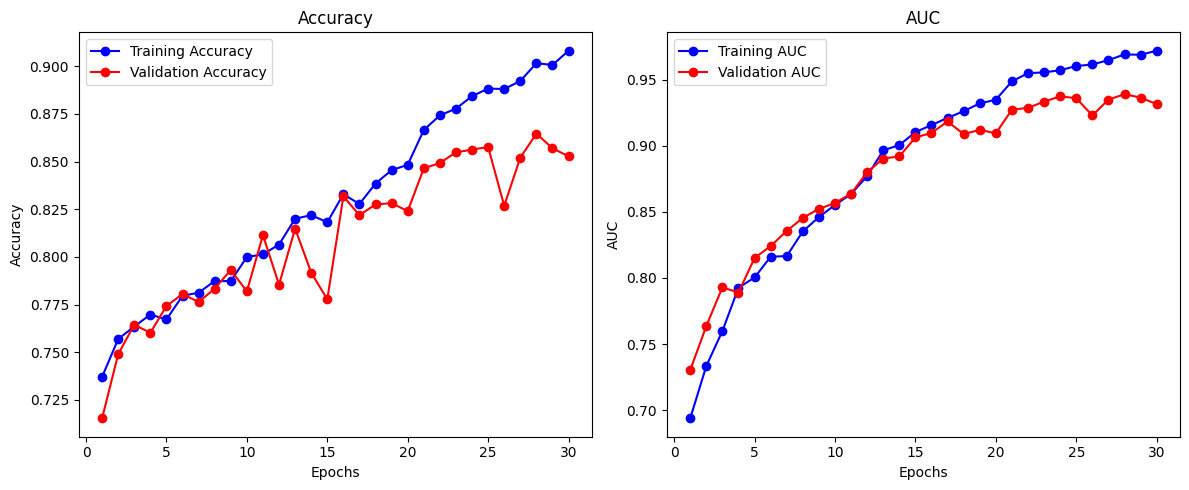

In [16]:
#visualizziamo l'andamento delle metriche durante l'addestramento
plot_training_metrics(history2)

In [38]:
#Facciamo le predizioni
y_pred_proba = model2.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step
Soglia ottimale: 0.236
Soglia ottimale: 0.23604494333267212


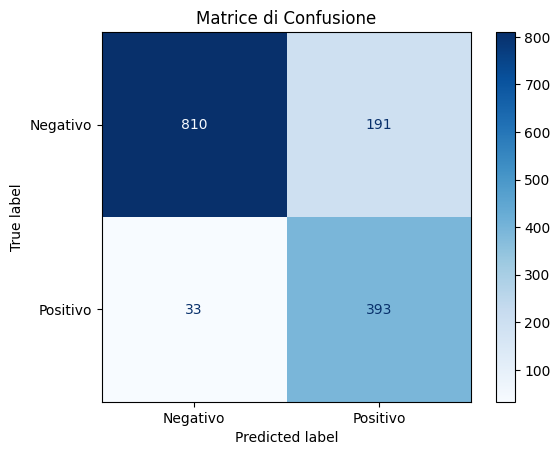

In [39]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm2 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm2)

In [40]:
#Vediamo i risultati
acc2 = accuracy_score(y_test, y_pred_binary)
auc2 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc2:.3f}")
print(f"AUC: {auc2:.3f}")

class_report2 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report2)
class_report2 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.843
AUC: 0.941
              precision    recall  f1-score   support

    Negativo       0.96      0.81      0.88      1001
    Positivo       0.67      0.92      0.78       426

    accuracy                           0.84      1427
   macro avg       0.82      0.87      0.83      1427
weighted avg       0.87      0.84      0.85      1427



In [31]:
!git pull origin CNN-model
from models import functions
from models.functions import compare_classification_reports

From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
Already up to date.


In [32]:
print(f"ACCURACY = modello 1: {acc1:.3f}, modello 2: {acc2:.3f}")
print(f"AUC = modello 1: {auc1:.3f}, modello 2: {auc2:.3f}")

ACCURACY = modello 1: 0.837, modello 2: 0.843
AUC = modello 1: 0.927, modello 2: 0.941


In [41]:
compare_classification_reports(class_report1, class_report2)

+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+
| Classe       |   Model 1 Precision |   Model 2 Precision |   Model 1 Recall |   Model 2 Recall |   Model 1 F1-Score |   Model 2 F1-Score |
+==============+=====================+=====================+==================+==================+====================+====================+
| 0            |               0.975 |               0.961 |            0.787 |            0.809 |              0.871 |              0.879 |
+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+
| 1            |               0.656 |               0.673 |            0.953 |            0.923 |              0.777 |              0.778 |
+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+
| macro avg  

In [47]:
model2.save('/content/drive/MyDrive/chagas_models/CNN_FL.keras')

#  Terzo modello: utilizzo dell'attenzione

In [44]:
from models.CNN import build_model_with_attention
from models.CNN.build_model_with_attention import *

In [46]:
model3 = build_cnn_multihead_attention_model()

#compiliamo il modello
model3.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("3_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history3 = model3.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.6822 - auc: 0.6980 - loss: 0.6270
Epoch 1: val_auc improved from -inf to 0.68335, saving model to 3_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.6822 - auc: 0.6980 - loss: 0.6270 - val_accuracy: 0.7286 - val_auc: 0.6833 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.6988 - auc: 0.7368 - loss: 0.5978
Epoch 2: val_auc improved from 0.68335 to 0.72899, saving model to 3_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.6988 - auc: 0.7368 - loss: 0.5977 - val_accuracy: 0.7041 - val_auc: 0.7290 - val_loss: 0.6387 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.7147 - auc: 0.7477 - loss: 0.5832
Epoch 3: val_auc did not improve from 0.72899
134/134 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.7146 - auc: 0.7476 - loss: 0.5833 - val_accuracy: 0.7244 - val_auc: 0.7261 - val_loss: 0.5947 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.7291 - auc: 0.7603 - loss: 0.5807
Epoch 4: val_auc improved from 0.72899 to 0.74155, saving model to 3_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7291 - auc: 0.7603 - loss: 0.5807 - val_accuracy: 0.7244 - val_auc: 0.7415 - val_loss: 0.6102 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.7502 - auc: 0.7708 - loss: 0.5699
Epoch 5: val_auc did not improve from 0.74155
134/134 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.7501 - auc: 0.7707 - loss: 0.5700 - val_accuracy: 0.6851 - val_auc: 0.7407 - val_loss: 0.6567 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.7171 - auc: 0.7649 - loss: 0.5812
Epoch 6: val_auc did not improve from 0.74155
134/134 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7171 - auc: 0.7649 - loss: 0.5811 - val_accuracy: 0.6220 - val_auc: 0.7413 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.7268 - auc: 0.7808 - loss: 0.5592
Epoch 7: val_auc improved from 0.74155 to 0.75415, saving model to 3_CNN_best_mo

134/134 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.7268 - auc: 0.7808 - loss: 0.5592 - val_accuracy: 0.6809 - val_auc: 0.7541 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.7402 - auc: 0.7747 - loss: 0.5581
Epoch 8: val_auc improved from 0.75415 to 0.75793, saving model to 3_CNN_best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7204 - auc: 0.7920 - loss: 0.5491 - val_accuracy: 0.7504 - val_auc: 0.7780 - val_loss: 0.5698 - learning_rate: 0.0010
Epoch 13/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.7461 - auc: 0.7881 - loss: 0.5538
Epoch 13: val_auc did not improve from 0.77797
134/134 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.7460 - auc: 0.7881 - loss: 0.5537 - val_accuracy: 0.6837 - val_auc: 0.7602 - val_loss: 0.6133 - learning_rate: 0.0010
Epoch 14/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.7636 - auc: 0.8180 - loss: 0.5172
Epoch 14: val_auc did not improve from 0.77797
134/134 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.7635 - auc: 0.8178 - loss: 0.5174 - val_accuracy: 0.5961 - val_auc: 0.7303 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 15/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.7425 - auc: 0.8110 - loss: 0.5246
Epoch 15: val_auc did not improve from 0.77797
134/134 ━━━━━━━━━━━━━━━━━━━━

134/134 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.7449 - auc: 0.8265 - loss: 0.5095 - val_accuracy: 0.7258 - val_auc: 0.7831 - val_loss: 0.5925 - learning_rate: 5.0000e-04
Epoch 18/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.7704 - auc: 0.8416 - loss: 0.4969
Epoch 18: val_auc did not improve from 0.78313
134/134 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.7704 - auc: 0.8416 - loss: 0.4969 - val_accuracy: 0.6136 - val_auc: 0.7748 - val_loss: 0.6944 - learning_rate: 5.0000e-04
Epoch 19/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.7616 - auc: 0.8329 - loss: 0.5067
Epoch 19: val_auc did not improve from 0.78313
134/134 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.7616 - auc: 0.8329 - loss: 0.5067 - val_accuracy: 0.7202 - val_auc: 0.7823 - val_loss: 0.5839 - learning_rate: 5.0000e-04
Epoch 20/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.7857 - auc: 0.8572 - loss: 0.4728
Epoch 20: val_auc did not improve from 0.78313
134/134 ━━━━━━━━

134/134 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8026 - auc: 0.8669 - loss: 0.4523 - val_accuracy: 0.6978 - val_auc: 0.7856 - val_loss: 0.6139 - learning_rate: 2.5000e-04
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.7770 - auc: 0.8604 - loss: 0.4591
Epoch 22: val_auc improved from 0.78563 to 0.79642, saving model to 3_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7771 - auc: 0.8604 - loss: 0.4591 - val_accuracy: 0.7202 - val_auc: 0.7964 - val_loss: 0.5945 - learning_rate: 2.5000e-04
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.7842 - auc: 0.8666 - loss: 0.4563
Epoch 23: val_auc improved from 0.79642 to 0.79805, saving model to 3_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7842 - auc: 0.8666 - loss: 0.4563 - val_accuracy: 0.7489 - val_auc: 0.7980 - val_loss: 0.5751 - learning_rate: 2.5000e-04
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.7940 - auc: 0.8716 - loss: 0.4495
Epoch 24: val_auc did not improve from 0.79805
134/134 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7940 - auc: 0.8716 - loss: 0.4495 - val_accuracy: 0.6417 - val_auc: 0.7738 - val_loss: 0.6927 - learning_rate: 2.5000e-04
Epoch 25/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.7713 - auc: 0.8651 - loss: 0.4583
Epoch 25: val_auc did not improve from 0.79805
134/134 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7714 - auc: 0.8651 - loss: 0.4583 - val_accuracy: 0.6606 - val_auc: 0.7787 - val_loss: 0.6958 - learning_rate: 2.5000e-04
Epoch 26/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.7946 - auc: 0.8703 - loss: 0.4552
Epoch 26: val_auc did not improve from 0.79805
134/134 ━━━━━━━━

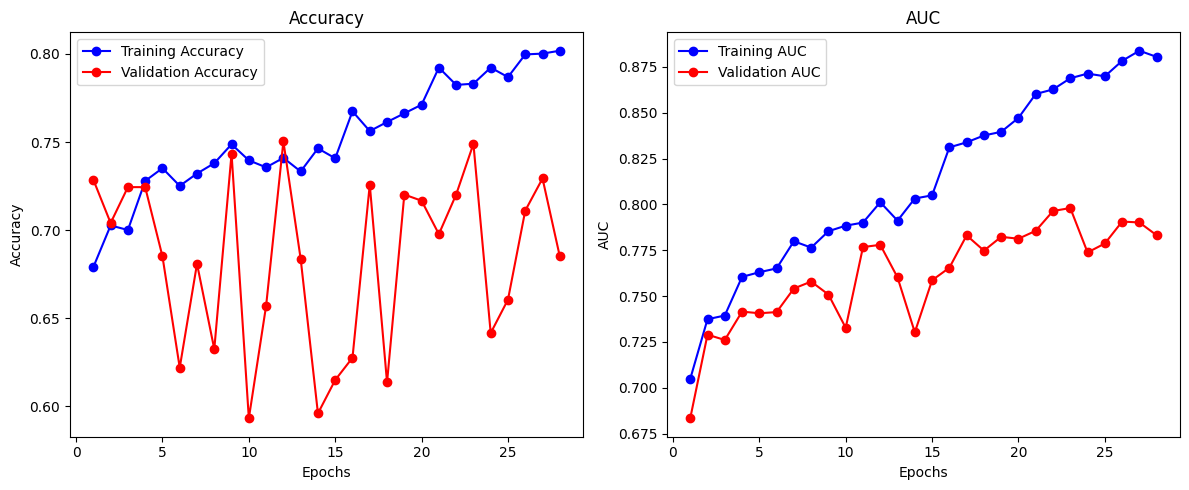

In [48]:
#visualizziamo l'andamento delle metriche durante l'addestramento
plot_training_metrics(history3)

In [49]:
#Facciamo le predizioni
y_pred_proba = model3.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 277ms/step
Soglia ottimale: 0.314
Soglia ottimale: 0.3137531578540802


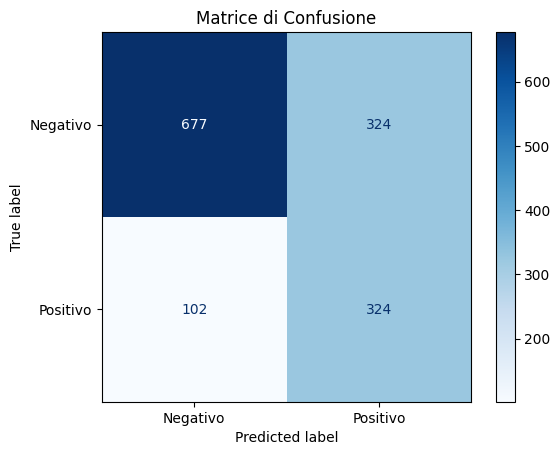

In [50]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm3 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm3)

In [51]:
#Vediamo i risultati
acc3 = accuracy_score(y_test, y_pred_binary)
auc3 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc3:.3f}")
print(f"AUC: {auc3:.3f}")

class_report3 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report3)
class_report3 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.701
AUC: 0.783
              precision    recall  f1-score   support

    Negativo       0.87      0.68      0.76      1001
    Positivo       0.50      0.76      0.60       426

    accuracy                           0.70      1427
   macro avg       0.68      0.72      0.68      1427
weighted avg       0.76      0.70      0.71      1427



In [52]:
model3.save('/content/drive/MyDrive/chagas_models/CNN_attention.keras')

# Quarto modello: uso SE

In [57]:
!git pull origin CNN-model
from importlib import reload
import models.CNN.build_model
reload(models.CNN.build_model)
from models.CNN.build_model import build_cnn_ecg_model

From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
Already up to date.


In [58]:
model4 = build_cnn_ecg_model(use_se= True)

#compiliamo il modello
model4.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("4_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history4 = model4.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.7078 - auc: 0.6738 - loss: 0.0493
Epoch 1: val_auc improved from -inf to 0.67536, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 100s 669ms/step - accuracy: 0.7081 - auc: 0.6741 - loss: 0.0492 - val_accuracy: 0.7132 - val_auc: 0.6754 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.7603 - auc: 0.7330 - loss: 0.0357
Epoch 2: val_auc improved from 0.67536 to 0.71913, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 88s 651ms/step - accuracy: 0.7604 - auc: 0.7330 - loss: 0.0357 - val_accuracy: 0.7335 - val_auc: 0.7191 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.7564 - auc: 0.7392 - loss: 0.0348
Epoch 3: val_auc improved from 0.71913 to 0.74192, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 145s 675ms/step - accuracy: 0.7565 - auc: 0.7392 - loss: 0.0348 - val_accuracy: 0.7539 - val_auc: 0.7419 - val_loss: 0.0367 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.7680 - auc: 0.7529 - loss: 0.0322
Epoch 4: val_auc improved from 0.74192 to 0.74531, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 144s 687ms/step - accuracy: 0.7679 - auc: 0.7529 - loss: 0.0322 - val_accuracy: 0.7398 - val_auc: 0.7453 - val_loss: 0.0354 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.7739 - auc: 0.7733 - loss: 0.0301
Epoch 5: val_auc improved from 0.74531 to 0.76630, saving model to 4_CNN_best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 146s 662ms/step - accuracy: 0.8637 - auc: 0.9501 - loss: 0.0099 - val_accuracy: 0.8310 - val_auc: 0.9205 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.8659 - auc: 0.9516 - loss: 0.0101
Epoch 23: val_auc improved from 0.92048 to 0.92423, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 140s 649ms/step - accuracy: 0.8660 - auc: 0.9516 - loss: 0.0101 - val_accuracy: 0.8373 - val_auc: 0.9242 - val_loss: 0.0169 - learning_rate: 0.0010
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.8775 - auc: 0.9582 - loss: 0.0090
Epoch 24: val_auc did not improve from 0.92423
134/134 ━━━━━━━━━━━━━━━━━━━━ 139s 627ms/step - accuracy: 0.8775 - auc: 0.9582 - loss: 0.0090 - val_accuracy: 0.8366 - val_auc: 0.9237 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 25/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.8784 - auc: 0.9569 - loss: 0.0093
Epoch 25: val_auc improved from 0.92423 to 0.93257, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 84s 629ms/step - accuracy: 0.8784 - auc: 0.9569 - loss: 0.0093 - val_accuracy: 0.8324 - val_auc: 0.9326 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 26/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.8822 - auc: 0.9624 - loss: 0.0085
Epoch 26: val_auc did not improve from 0.93257
134/134 ━━━━━━━━━━━━━━━━━━━━ 85s 632ms/step - accuracy: 0.8822 - auc: 0.9624 - loss: 0.0085 - val_accuracy: 0.8401 - val_auc: 0.9312 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 27/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.8842 - auc: 0.9632 - loss: 0.0079
Epoch 27: val_auc improved from 0.93257 to 0.93312, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 632ms/step - accuracy: 0.8842 - auc: 0.9632 - loss: 0.0079 - val_accuracy: 0.8499 - val_auc: 0.9331 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 28/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8882 - auc: 0.9636 - loss: 0.0079
Epoch 28: val_auc did not improve from 0.93312
134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 633ms/step - accuracy: 0.8882 - auc: 0.9636 - loss: 0.0079 - val_accuracy: 0.8303 - val_auc: 0.9230 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 29/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8885 - auc: 0.9645 - loss: 0.0075
Epoch 29: val_auc improved from 0.93312 to 0.93582, saving model to 4_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 645ms/step - accuracy: 0.8885 - auc: 0.9645 - loss: 0.0075 - val_accuracy: 0.8576 - val_auc: 0.9358 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 30/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.9018 - auc: 0.9719 - loss: 0.0063
Epoch 30: val_auc did not improve from 0.93582
134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 641ms/step - accuracy: 0.9017 - auc: 0.9718 - loss: 0.0063 - val_accuracy: 0.8359 - val_auc: 0.9205 - val_loss: 0.0224 - learning_rate: 0.0010


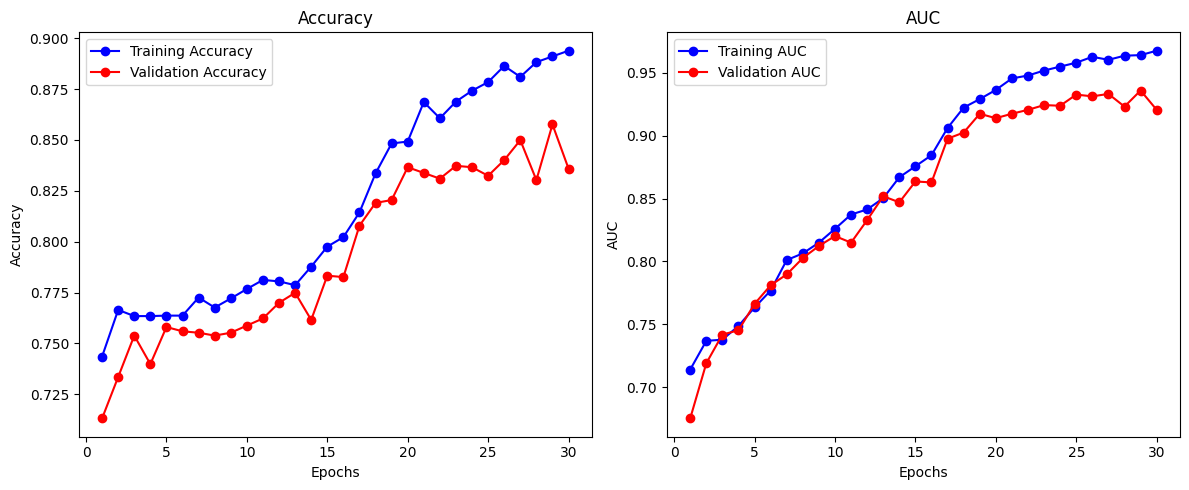

In [59]:
#visualizziamo l'andamento delle metriche durante l'addestramento
plot_training_metrics(history4)

In [60]:
#Facciamo le predizioni
y_pred_proba = model4.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step
Soglia ottimale: 0.394
Soglia ottimale: 0.3942795991897583


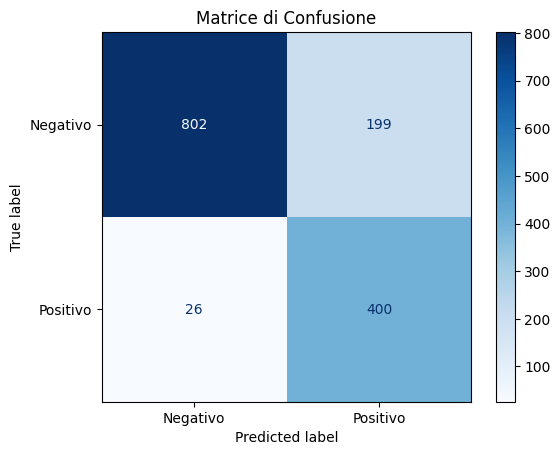

In [61]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm4 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm4)

In [62]:
#Vediamo i risultati
acc4 = accuracy_score(y_test, y_pred_binary)
auc4 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc4:.3f}")
print(f"AUC: {auc4:.3f}")

class_report4 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report4)
class_report4 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.842
AUC: 0.938
              precision    recall  f1-score   support

    Negativo       0.97      0.80      0.88      1001
    Positivo       0.67      0.94      0.78       426

    accuracy                           0.84      1427
   macro avg       0.82      0.87      0.83      1427
weighted avg       0.88      0.84      0.85      1427



In [63]:
model4.save('/content/drive/MyDrive/chagas_models/CNN_attention.keras')

In [64]:
print(f"ACCURACY = modello 1: {acc1:.3f}, modello 2: {acc2:.3f}, modello 3: {acc3:.3f}, modello 4: {acc4:.3f}")
print(f"AUC = modello 1: {auc1:.3f}, modello 2: {auc2:.3f}, modello 3: {auc3:.3f}, modello 4: {auc4:.3f}")

ACCURACY = modello 1: 0.837, modello 2: 0.843, modello 3: 0.701, modello 4: 0.842
AUC = modello 1: 0.927, modello 2: 0.941, modello 3: 0.783, modello 4: 0.938


# Quinto modello: uso residual connection

In [75]:
!git pull origin CNN-model
import models.CNN.build_model_residual_connections
from models.CNN.build_model_residual_connections import *

From https://github.com/dokunoale/chagas
 * branch            CNN-model  -> FETCH_HEAD
Already up to date.


In [76]:
model5 = build_resnet_ecg_model(use_se= True, dropout_rate=0.5)

#compiliamo il modello
model5.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("5_CNN")

cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

history5 = model5.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=callback)


Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7123 - auc: 0.6185 - loss: 0.0627
Epoch 1: val_auc improved from -inf to 0.72698, saving model to 5_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.7124 - auc: 0.6188 - loss: 0.0626 - val_accuracy: 0.7020 - val_auc: 0.7270 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7417 - auc: 0.7120 - loss: 0.0368
Epoch 2: val_auc improved from 0.72698 to 0.74281, saving model to 5_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.7418 - auc: 0.7120 - loss: 0.0368 - val_accuracy: 0.7286 - val_auc: 0.7428 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7604 - auc: 0.7318 - loss: 0.0341
Epoch 3: val_auc improved from 0.74281 to 0.74934, saving model to 5_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7604 - auc: 0.7318 - loss: 0.0341 - val_accuracy: 0.7167 - val_auc: 0.7493 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7573 - auc: 0.7491 - loss: 0.0344
Epoch 4: val_auc improved from 0.74934 to 0.77990, saving model to 5_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7573 - auc: 0.7492 - loss: 0.0344 - val_accuracy: 0.7286 - val_auc: 0.7799 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7654 - auc: 0.7855 - loss: 0.0317
Epoch 5: val_auc did not improve from 0.77990
134/134 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.7655 - auc: 0.7854 - loss: 0.0317 - val_accuracy: 0.7504 - val_auc: 0.7672 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7670 - auc: 0.7779 - loss: 0.0316
Epoch 6: val_auc improved from 0.77990 to 0.81035, saving model to 5_CNN_best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.8182 - auc: 0.9204 - loss: 0.0162 - val_accuracy: 0.8086 - val_auc: 0.8987 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 14/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8382 - auc: 0.9335 - loss: 0.0140
Epoch 14: val_auc improved from 0.89867 to 0.91095, saving model to 5_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.8381 - auc: 0.9335 - loss: 0.0140 - val_accuracy: 0.8303 - val_auc: 0.9110 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 15/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8441 - auc: 0.9292 - loss: 0.0143
Epoch 15: val_auc improved from 0.91095 to 0.91568, saving model to 5_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8441 - auc: 0.9293 - loss: 0.0143 - val_accuracy: 0.8289 - val_auc: 0.9157 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 16/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8441 - auc: 0.9410 - loss: 0.0126
Epoch 16: val_auc did not improve from 0.91568
134/134 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.8441 - auc: 0.9410 - loss: 0.0126 - val_accuracy: 0.8212 - val_auc: 0.9010 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 17/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8572 - auc: 0.9408 - loss: 0.0133
Epoch 17: val_auc did not improve from 0.91568
134/134 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.8572 - auc: 0.9408 - loss: 0.0133 - val_accuracy: 0.8100 - val_auc: 0.9031 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 18/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8656 - auc: 0.9460 - loss: 0.0118
Epoch 18: val_auc did not improve from 0.91568
134/134 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/

134/134 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8747 - auc: 0.9530 - loss: 0.0104 - val_accuracy: 0.8387 - val_auc: 0.9166 - val_loss: 0.0208 - learning_rate: 5.0000e-04
Epoch 20/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8885 - auc: 0.9627 - loss: 0.0081
Epoch 20: val_auc improved from 0.91662 to 0.92555, saving model to 5_CNN_best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.8885 - auc: 0.9627 - loss: 0.0081 - val_accuracy: 0.8422 - val_auc: 0.9256 - val_loss: 0.0177 - learning_rate: 5.0000e-04
Epoch 21/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8821 - auc: 0.9586 - loss: 0.0087
Epoch 21: val_auc did not improve from 0.92555
134/134 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.8821 - auc: 0.9585 - loss: 0.0087 - val_accuracy: 0.8317 - val_auc: 0.9169 - val_loss: 0.0215 - learning_rate: 5.0000e-04
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8961 - auc: 0.9644 - loss: 0.0081
Epoch 22: val_auc did not improve from 0.92555
134/134 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8962 - auc: 0.9644 - loss: 0.0081 - val_accuracy: 0.8366 - val_auc: 0.9183 - val_loss: 0.0223 - learning_rate: 5.0000e-04
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8931 - auc: 0.9655 - loss: 0.0080
Epoch 23: val_auc did not improve from 0.92555
134/134 ━━━━━━━━━━━━━━━━━

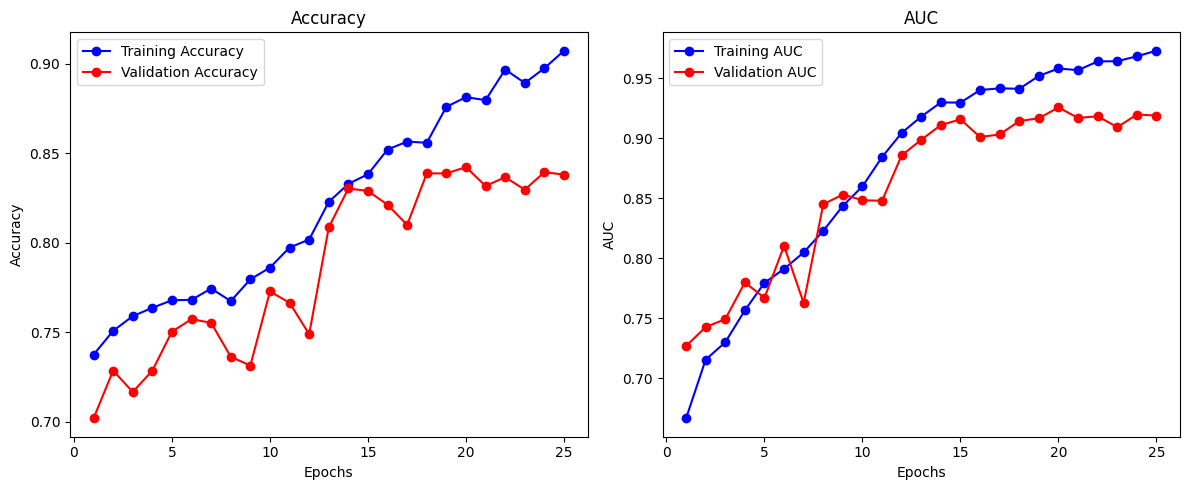

In [77]:
#visualizziamo l'andamento delle metriche durante l'addestramento
plot_training_metrics(history5)

In [78]:
#Facciamo le predizioni
y_pred_proba = model5.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)
print(f"Soglia ottimale: {optimal_threshold}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 326ms/step
Soglia ottimale: 0.371
Soglia ottimale: 0.3711678683757782


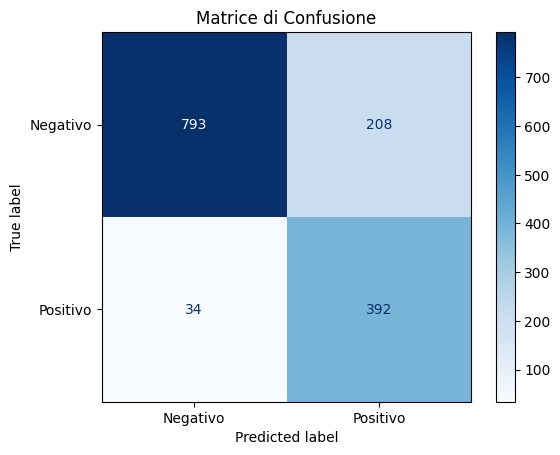

In [79]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm5 = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm5)

In [80]:
#Vediamo i risultati
acc5 = accuracy_score(y_test, y_pred_binary)
auc5 = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc5:.3f}")
print(f"AUC: {auc5:.3f}")

class_report5 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report5)
class_report5 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.830
AUC: 0.918
              precision    recall  f1-score   support

    Negativo       0.96      0.79      0.87      1001
    Positivo       0.65      0.92      0.76       426

    accuracy                           0.83      1427
   macro avg       0.81      0.86      0.82      1427
weighted avg       0.87      0.83      0.84      1427



In [81]:
model5.save('/content/drive/MyDrive/chagas_models/CNN_resnet.keras')